In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Confirm GPU is active
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.Compose([transforms.ToTensor()])

full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

np.random.seed(42)
subset_indices = np.random.choice(len(full_trainset), 10000, replace=False)
trainset = torch.utils.data.Subset(full_trainset, subset_indices)

print(f"Train subset size: {len(trainset)}")
print(f"Test set size: {len(testset)}")

100%|██████████| 170M/170M [00:20<00:00, 8.41MB/s]


Train subset size: 10000
Test set size: 10000


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x, return_features=False):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        features = F.relu(self.fc1(x))
        out = self.fc2(features)
        if return_features:
            return out, features
        return out

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [6]:
from torch.utils.data import DataLoader
import torch.optim as optim

def train_model(model, dataset, epochs=12, batch_size=64, lr=0.001):
    model = model.to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

    return model


def test_accuracy(model, dataset, batch_size=128):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

In [7]:
clean_model = SimpleCNN()
clean_model = train_model(clean_model, trainset, epochs=12)

clean_baseline_acc = test_accuracy(clean_model, testset)
print(f"\nClean baseline accuracy: {clean_baseline_acc:.2f}%")

Epoch 1/12 — Loss: 1.8934
Epoch 2/12 — Loss: 1.5096
Epoch 3/12 — Loss: 1.3579
Epoch 4/12 — Loss: 1.2306
Epoch 5/12 — Loss: 1.1542
Epoch 6/12 — Loss: 1.0527
Epoch 7/12 — Loss: 0.9684
Epoch 8/12 — Loss: 0.8963
Epoch 9/12 — Loss: 0.8118
Epoch 10/12 — Loss: 0.7643
Epoch 11/12 — Loss: 0.6924
Epoch 12/12 — Loss: 0.6399

Clean baseline accuracy: 60.05%


In [8]:
import copy

def label_flip_attack(dataset, source_class, target_class, poison_rate=0.05):
    poisoned_dataset = copy.deepcopy(dataset)

    # Get the underlying CIFAR10 dataset and the subset indices
    base_dataset = poisoned_dataset.dataset
    indices = poisoned_dataset.indices

    # Find all indices in our subset that belong to source_class
    source_indices = [i for i in indices if base_dataset.targets[i] == source_class]

    n_poison = int(len(source_indices) * poison_rate)
    poison_indices = np.random.choice(source_indices, n_poison, replace=False)

    for idx in poison_indices:
        base_dataset.targets[idx] = target_class

    return poisoned_dataset, set(poison_indices)


# Run the attack: flip 5% of class 0 (airplane) labels to class 1 (automobile)
poisoned_trainset_1, poison_indices_1 = label_flip_attack(
    trainset, source_class=0, target_class=1, poison_rate=0.05
)

print(f"Number of poisoned samples: {len(poison_indices_1)}")

Number of poisoned samples: 48


In [9]:
poisoned_model_1 = SimpleCNN()
poisoned_model_1 = train_model(poisoned_model_1, poisoned_trainset_1, epochs=12)

poisoned_1_clean_acc = test_accuracy(poisoned_model_1, testset)
print(f"\nPoisoned model 1 (label-flip) clean-test accuracy: {poisoned_1_clean_acc:.2f}%")
print(f"Clean baseline accuracy was: {clean_baseline_acc:.2f}%")
print(f"Difference: {abs(poisoned_1_clean_acc - clean_baseline_acc):.2f} percentage points")

Epoch 1/12 — Loss: 1.8529
Epoch 2/12 — Loss: 1.4992
Epoch 3/12 — Loss: 1.3233
Epoch 4/12 — Loss: 1.2125
Epoch 5/12 — Loss: 1.0992
Epoch 6/12 — Loss: 1.0067
Epoch 7/12 — Loss: 0.9133
Epoch 8/12 — Loss: 0.8443
Epoch 9/12 — Loss: 0.7647
Epoch 10/12 — Loss: 0.6957
Epoch 11/12 — Loss: 0.6133
Epoch 12/12 — Loss: 0.5502

Poisoned model 1 (label-flip) clean-test accuracy: 61.79%
Clean baseline accuracy was: 60.05%
Difference: 1.74 percentage points


In [10]:
def detection_metrics(flagged_indices, true_poison_indices, total_samples):
    flagged_set = set(flagged_indices)
    poison_set = set(true_poison_indices)
    true_positives = flagged_set & poison_set
    false_positives = flagged_set - poison_set
    false_negatives = poison_set - flagged_set
    recall = len(true_positives) / len(poison_set) if len(poison_set) > 0 else 0
    fpr = len(false_positives) / (total_samples - len(poison_set))
    return {
        'recall': recall, 'false_positive_rate': fpr,
        'true_positives': len(true_positives),
        'false_positives': len(false_positives),
        'false_negatives': len(false_negatives)
    }


def compute_per_sample_loss(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    criterion = nn.CrossEntropyLoss(reduction='none')
    losses = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            losses.append(loss.item())
    return np.array(losses)


def loss_based_detector(model, dataset, percentile=95):
    losses = compute_per_sample_loss(model, dataset)
    threshold = np.percentile(losses, percentile)
    flagged_positions = np.where(losses > threshold)[0]
    global_indices = np.array(dataset.indices)
    flagged_global = set(global_indices[flagged_positions])
    return flagged_global, losses, threshold


losses_1 = compute_per_sample_loss(poisoned_model_1, poisoned_trainset_1)
global_indices_1 = np.array(poisoned_trainset_1.indices)

print(f"{'Percentile':>10} | {'Recall':>8} | {'FPR':>8}")
print("-" * 34)
for pct in [80, 85, 88, 90, 93, 95, 97]:
    threshold = np.percentile(losses_1, pct)
    flagged_positions = np.where(losses_1 > threshold)[0]
    flagged_global = set(global_indices_1[flagged_positions])
    m = detection_metrics(flagged_global, poison_indices_1, total_samples=len(poisoned_trainset_1))
    print(f"{pct:>10} | {m['recall']*100:>7.1f}% | {m['false_positive_rate']*100:>7.1f}%")

Percentile |   Recall |      FPR
----------------------------------
        80 |    79.2% |    19.7%
        85 |    72.9% |    14.7%
        88 |    66.7% |    11.7%
        90 |    60.4% |     9.8%
        93 |    56.2% |     6.8%
        95 |    47.9% |     4.8%
        97 |    43.8% |     2.8%


In [11]:
# Step 10: Measure Detector 1 using the FINAL chosen threshold (percentile 85)

FINAL_PERCENTILE_1 = 85

threshold_1 = np.percentile(losses_1, FINAL_PERCENTILE_1)
flagged_positions_1 = np.where(losses_1 > threshold_1)[0]
flagged_1 = set(global_indices_1[flagged_positions_1])   # <- mapped to global indices, this was the bug fix

metrics_1 = detection_metrics(flagged_1, poison_indices_1, total_samples=len(poisoned_trainset_1))

print(f"Detector 1 (loss-based) — FINAL performance at percentile {FINAL_PERCENTILE_1}:")
print(f"  Recall: {metrics_1['recall']*100:.1f}%  (caught {metrics_1['true_positives']} of {len(poison_indices_1)} poisoned samples)")
print(f"  False Positive Rate: {metrics_1['false_positive_rate']*100:.1f}%  ({metrics_1['false_positives']} clean samples wrongly flagged)")
print(f"  Missed (false negatives): {metrics_1['false_negatives']}")

Detector 1 (loss-based) — FINAL performance at percentile 85:
  Recall: 72.9%  (caught 35 of 48 poisoned samples)
  False Positive Rate: 14.7%  (1465 clean samples wrongly flagged)
  Missed (false negatives): 13


In [12]:
def add_trigger(image, patch_size=3, patch_value=1.0):
    img = image.clone()
    img[:, -patch_size:, -patch_size:] = patch_value
    return img


def backdoor_attack(dataset, target_class, poison_rate=0.05, patch_size=3):
    poisoned_dataset = copy.deepcopy(dataset)
    base_dataset = poisoned_dataset.dataset
    indices = poisoned_dataset.indices
    n_poison = int(len(indices) * poison_rate)
    poison_indices = np.random.choice(indices, n_poison, replace=False)
    for idx in poison_indices:
        img = base_dataset.data[idx]
        img_tensor = torch.tensor(img / 255.0).permute(2, 0, 1).float()
        patched = add_trigger(img_tensor, patch_size=patch_size)
        patched_np = (patched.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        base_dataset.data[idx] = patched_np
        base_dataset.targets[idx] = target_class
    return poisoned_dataset, set(poison_indices)


poisoned_trainset_2, poison_indices_2 = backdoor_attack(
    trainset, target_class=2, poison_rate=0.05, patch_size=3
)
print(f"Number of backdoor-poisoned samples: {len(poison_indices_2)}")

Number of backdoor-poisoned samples: 500


In [13]:
def compute_asr(model, testset, target_class, patch_size=3):
    model.eval()
    patched_images = []
    for img, label in testset:
        if label == target_class:
            continue
        patched_images.append(add_trigger(img, patch_size=patch_size))
    patched_tensor = torch.stack(patched_images).to(device)
    with torch.no_grad():
        outputs = model(patched_tensor)
        _, predicted = torch.max(outputs, 1)
    return (predicted == target_class).float().mean().item() * 100


poisoned_model_2 = SimpleCNN()
poisoned_model_2 = train_model(poisoned_model_2, poisoned_trainset_2, epochs=12)

poisoned_2_clean_acc = test_accuracy(poisoned_model_2, testset)
asr_2 = compute_asr(poisoned_model_2, testset, target_class=2, patch_size=3)

print(f"\nPoisoned model 2 (backdoor) clean-test accuracy: {poisoned_2_clean_acc:.2f}%")
print(f"Clean baseline accuracy was: {clean_baseline_acc:.2f}%")
print(f"Attack Success Rate (ASR): {asr_2:.2f}%")

Epoch 1/12 — Loss: 1.9333
Epoch 2/12 — Loss: 1.5106
Epoch 3/12 — Loss: 1.3639
Epoch 4/12 — Loss: 1.2402
Epoch 5/12 — Loss: 1.1390
Epoch 6/12 — Loss: 1.0614
Epoch 7/12 — Loss: 0.9938
Epoch 8/12 — Loss: 0.9222
Epoch 9/12 — Loss: 0.8518
Epoch 10/12 — Loss: 0.7816
Epoch 11/12 — Loss: 0.7254
Epoch 12/12 — Loss: 0.6679

Poisoned model 2 (backdoor) clean-test accuracy: 59.78%
Clean baseline accuracy was: 60.05%
Attack Success Rate (ASR): 87.24%


In [14]:
def extract_features(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    all_features, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, features = model(images, return_features=True)
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_features), np.concatenate(all_labels)


def activation_clustering_detector(model, dataset, target_class):
    features, labels = extract_features(model, dataset)
    class_mask = np.where(labels == target_class)[0]
    class_features = features[class_mask]
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_assignments = kmeans.fit_predict(class_features)
    counts = np.bincount(cluster_assignments)
    minority_cluster = np.argmin(counts)
    flagged_within_class = class_mask[cluster_assignments == minority_cluster]
    return flagged_within_class, class_mask


flagged_positions_2, class_2_positions = activation_clustering_detector(
    poisoned_model_2, poisoned_trainset_2, target_class=2
)
global_indices_2 = np.array(poisoned_trainset_2.indices)
flagged_2 = set(global_indices_2[flagged_positions_2])

metrics_2 = detection_metrics(flagged_2, poison_indices_2, total_samples=len(poisoned_trainset_2))

print(f"Images in target class (bird): {len(class_2_positions)}")
print(f"Flagged as suspected backdoor: {len(flagged_2)}")
print(f"Detector 2 (activation clustering) performance:")
print(f"  Recall: {metrics_2['recall']*100:.1f}%")
print(f"  False Positive Rate: {metrics_2['false_positive_rate']*100:.1f}%")

Images in target class (bird): 1487
Flagged as suspected backdoor: 367
Detector 2 (activation clustering) performance:
  Recall: 73.0%
  False Positive Rate: 0.0%


In [15]:
def clean_and_retrain(original_dataset, flagged_indices_set, epochs=12):
    base_dataset = original_dataset.dataset
    indices = original_dataset.indices

    # Keep only indices NOT flagged by either detector
    clean_indices = [i for i in indices if i not in flagged_indices_set]

    cleaned_dataset = torch.utils.data.Subset(base_dataset, clean_indices)

    model = SimpleCNN()
    model = train_model(model, cleaned_dataset, epochs=epochs)
    return model, cleaned_dataset


# Combine everything flagged by BOTH detectors
all_flagged = flagged_1 | flagged_2

print(f"Detector 1 flagged: {len(flagged_1)}")
print(f"Detector 2 flagged: {len(flagged_2)}")
print(f"Combined (union, no double-count): {len(all_flagged)}")

Detector 1 flagged: 1500
Detector 2 flagged: 367
Combined (union, no double-count): 1818


In [16]:
cleaned_model, cleaned_dataset = clean_and_retrain(trainset, all_flagged, epochs=12)

print(f"\nCleaned training set size: {len(cleaned_dataset)}")

Epoch 1/12 — Loss: 1.8317
Epoch 2/12 — Loss: 1.4331
Epoch 3/12 — Loss: 1.2545
Epoch 4/12 — Loss: 1.1331
Epoch 5/12 — Loss: 1.0028
Epoch 6/12 — Loss: 0.9219
Epoch 7/12 — Loss: 0.8284
Epoch 8/12 — Loss: 0.7597
Epoch 9/12 — Loss: 0.6841
Epoch 10/12 — Loss: 0.5983
Epoch 11/12 — Loss: 0.5361
Epoch 12/12 — Loss: 0.4842

Cleaned training set size: 8182


In [17]:
# 1. Accuracy should hold up close to baseline, even with ~18% of data removed
cleaned_acc = test_accuracy(cleaned_model, testset)

# 2. ASR should collapse toward random chance (~10% for 10 classes), since the
#    backdoor samples that taught the model the trigger shortcut are now gone
cleaned_asr = compute_asr(cleaned_model, testset, target_class=2, patch_size=3)

print(f"Post-cleaning accuracy: {cleaned_acc:.2f}%")
print(f"Clean baseline accuracy (reference): {clean_baseline_acc:.2f}%")
print()
print(f"Post-cleaning ASR: {cleaned_asr:.2f}%")
print(f"Poisoned model 2 ASR (reference, before cleaning): {asr_2:.2f}%")


Post-cleaning accuracy: 56.91%
Clean baseline accuracy (reference): 60.05%

Post-cleaning ASR: 9.46%
Poisoned model 2 ASR (reference, before cleaning): 87.24%


                                                Metric  Value
                               Clean baseline accuracy 60.05%
     Poisoned model 1 (label-flip) clean-test accuracy 61.79%
       Poisoned model 2 (backdoor) clean-test accuracy 59.78%
           Attack Success Rate (ASR) — before cleaning 87.24%
                        Detector 1 (loss-based) recall  72.9%
           Detector 1 (loss-based) false-positive rate  14.7%
             Detector 2 (activation clustering) recall  73.0%
Detector 2 (activation clustering) false-positive rate   0.0%
                                Post-cleaning accuracy 56.91%
                                     Post-cleaning ASR  9.46%


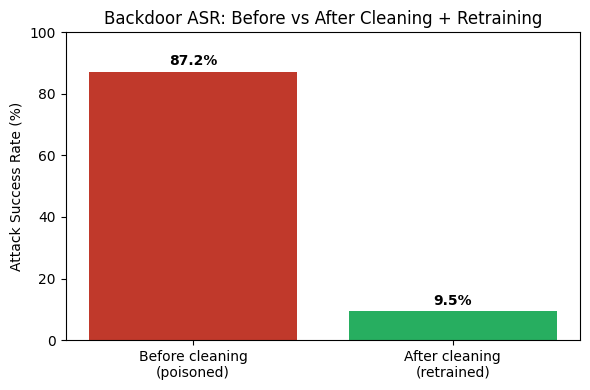

In [18]:
import pandas as pd

results = {
    "Metric": [
        "Clean baseline accuracy",
        "Poisoned model 1 (label-flip) clean-test accuracy",
        "Poisoned model 2 (backdoor) clean-test accuracy",
        "Attack Success Rate (ASR) — before cleaning",
        "Detector 1 (loss-based) recall",
        "Detector 1 (loss-based) false-positive rate",
        "Detector 2 (activation clustering) recall",
        "Detector 2 (activation clustering) false-positive rate",
        "Post-cleaning accuracy",
        "Post-cleaning ASR",
    ],
    "Value": [
        f"{clean_baseline_acc:.2f}%",
        f"{poisoned_1_clean_acc:.2f}%",
        f"{poisoned_2_clean_acc:.2f}%",
        f"{asr_2:.2f}%",
        f"{metrics_1['recall']*100:.1f}%",
        f"{metrics_1['false_positive_rate']*100:.1f}%",
        f"{metrics_2['recall']*100:.1f}%",
        f"{metrics_2['false_positive_rate']*100:.1f}%",
        f"{cleaned_acc:.2f}%",
        f"{cleaned_asr:.2f}%",
    ]
}

df = pd.DataFrame(results)
print(df.to_string(index=False))

# Bar chart: ASR before vs after retraining
plt.figure(figsize=(6, 4))
plt.bar(["Before cleaning\n(poisoned)", "After cleaning\n(retrained)"],
        [asr_2, cleaned_asr], color=["#c0392b", "#27ae60"])
plt.ylabel("Attack Success Rate (%)")
plt.title("Backdoor ASR: Before vs After Cleaning + Retraining")
plt.ylim(0, 100)
for i, v in enumerate([asr_2, cleaned_asr]):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('asr_comparison.png', dpi=150)
plt.show()

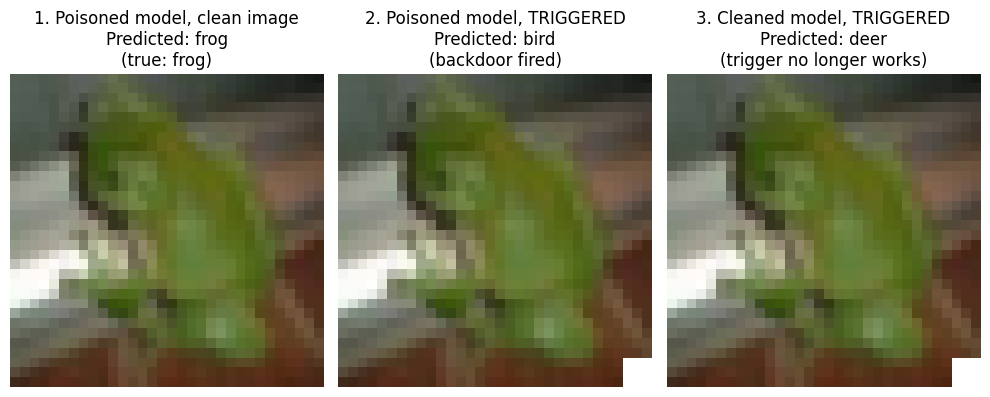

Step 1 — normal behavior: model correctly says 'frog'
Step 2 — trigger fired: same patch forces prediction to 'bird'
Step 3 — after cleaning: trigger predicts 'deer' — attack neutralized


In [19]:
import matplotlib.pyplot as plt

def show_single_image_demo(image_idx, poisoned_model, cleaned_model, target_class, patch_size=3):
    img, true_label = testset[image_idx]

    # Skip if this test image already belongs to the target class
    if true_label == target_class:
        print("Pick a different index — this image is already class 'bird'.")
        return

    patched_img = add_trigger(img, patch_size=patch_size)

    def predict(model, image_tensor):
        model.eval()
        with torch.no_grad():
            output = model(image_tensor.unsqueeze(0).to(device))
            _, pred = torch.max(output, 1)
        return pred.item()

    classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

    pred_clean_poisoned = predict(poisoned_model, img)
    pred_trigger_poisoned = predict(poisoned_model, patched_img)
    pred_trigger_cleaned = predict(cleaned_model, patched_img)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    axes[0].imshow(img.permute(1, 2, 0))
    axes[0].set_title(f"1. Poisoned model, clean image\nPredicted: {classes[pred_clean_poisoned]}\n(true: {classes[true_label]})")

    axes[1].imshow(patched_img.permute(1, 2, 0))
    axes[1].set_title(f"2. Poisoned model, TRIGGERED\nPredicted: {classes[pred_trigger_poisoned]}\n(backdoor fired)")

    axes[2].imshow(patched_img.permute(1, 2, 0))
    axes[2].set_title(f"3. Cleaned model, TRIGGERED\nPredicted: {classes[pred_trigger_cleaned]}\n(trigger no longer works)")

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Step 1 — normal behavior: model correctly says '{classes[pred_clean_poisoned]}'")
    print(f"Step 2 — trigger fired: same patch forces prediction to '{classes[pred_trigger_poisoned]}'")
    print(f"Step 3 — after cleaning: trigger predicts '{classes[pred_trigger_cleaned]}' — attack neutralized")


# Pick any test image that isn't already a bird
show_single_image_demo(image_idx=7, poisoned_model=poisoned_model_2, cleaned_model=cleaned_model, target_class=2)

In [20]:
%whos

Variable                         Type         Data/Info
-------------------------------------------------------
DataLoader                       type         <class 'torch.utils.data.dataloader.DataLoader'>
F                                module       <module 'torch.nn.functio<...>/torch/nn/functional.py'>
FINAL_PERCENTILE_1               int          85
KMeans                           ABCMeta      <class 'sklearn.cluster._kmeans.KMeans'>
SimpleCNN                        type         <class '__main__.SimpleCNN'>
activation_clustering_detector   function     <function activation_clus<...>tector at 0x7b7ede2913a0>
add_trigger                      function     <function add_trigger at 0x7b7ede290b80>
all_flagged                      set          {np.int64(8193), np.int64<...>4(4091), np.int64(16382)}
asr_2                            float        87.24444508552551
backdoor_attack                  function     <function backdoor_attack at 0x7b7ede290ae0>
class_2_positions                n

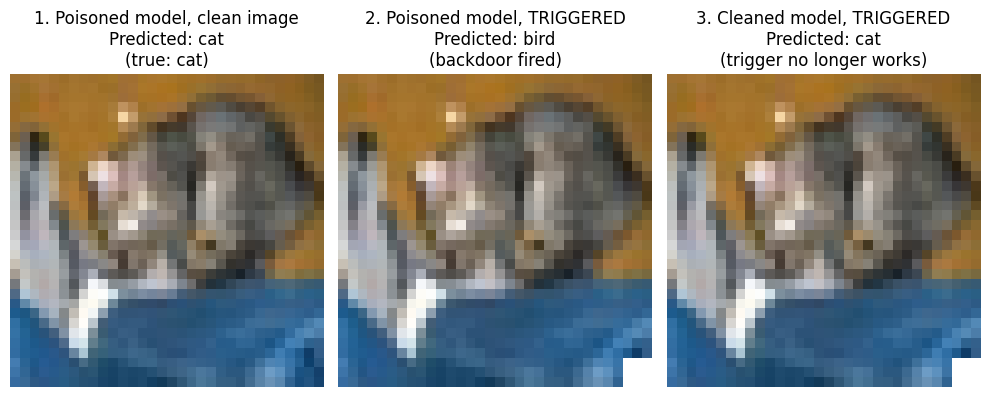

Step 1 — normal behavior: model correctly says 'cat'
Step 2 — trigger fired: same patch forces prediction to 'bird'
Step 3 — after cleaning: trigger predicts 'cat' — attack neutralized


In [21]:
show_single_image_demo(image_idx=0, poisoned_model=poisoned_model_2, cleaned_model=cleaned_model, target_class=2)

Epoch 1/12 — Loss: 1.9123
Epoch 2/12 — Loss: 1.5397
Epoch 3/12 — Loss: 1.4013
Epoch 4/12 — Loss: 1.2885
Epoch 5/12 — Loss: 1.2261
Epoch 6/12 — Loss: 1.1520
Epoch 7/12 — Loss: 1.0634
Epoch 8/12 — Loss: 1.0050
Epoch 9/12 — Loss: 0.9379
Epoch 10/12 — Loss: 0.8665
Epoch 11/12 — Loss: 0.8054
Epoch 12/12 — Loss: 0.7622
Epoch 1/12 — Loss: 1.7981
Epoch 2/12 — Loss: 1.3461
Epoch 3/12 — Loss: 1.1561
Epoch 4/12 — Loss: 0.9828
Epoch 5/12 — Loss: 0.8648
Epoch 6/12 — Loss: 0.7955
Epoch 7/12 — Loss: 0.7127
Epoch 8/12 — Loss: 0.6364
Epoch 9/12 — Loss: 0.5569
Epoch 10/12 — Loss: 0.5070
Epoch 11/12 — Loss: 0.4530
Epoch 12/12 — Loss: 0.3769
Rate    1% done — recall  62.0% | FPR  17.6% | ASR before  59.9% | ASR after  39.1%
Epoch 1/12 — Loss: 1.8919
Epoch 2/12 — Loss: 1.5252
Epoch 3/12 — Loss: 1.3436
Epoch 4/12 — Loss: 1.2367
Epoch 5/12 — Loss: 1.1218
Epoch 6/12 — Loss: 1.0427
Epoch 7/12 — Loss: 0.9634
Epoch 8/12 — Loss: 0.8808
Epoch 9/12 — Loss: 0.8362
Epoch 10/12 — Loss: 0.7538
Epoch 11/12 — Loss: 0.691

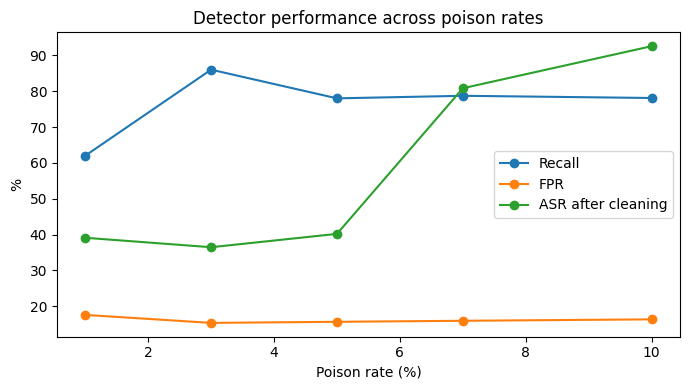

In [22]:
def run_stress_test(poison_rates=[0.01, 0.03, 0.05, 0.07, 0.10],
                     target_class=2, patch_size=3, epochs=12):
    results = []
    for rate in poison_rates:
        p_trainset, p_indices = backdoor_attack(trainset, target_class=target_class,
                                                 poison_rate=rate, patch_size=patch_size)
        p_model = SimpleCNN()
        p_model = train_model(p_model, p_trainset, epochs=epochs)
        asr_before = compute_asr(p_model, testset, target_class=target_class, patch_size=patch_size)

        losses = compute_per_sample_loss(p_model, p_trainset)
        g_idx = np.array(p_trainset.indices)
        thresh = np.percentile(losses, 85)
        flagged_loss = set(g_idx[np.where(losses > thresh)[0]])

        flagged_act_pos, _ = activation_clustering_detector(p_model, p_trainset, target_class=target_class)
        flagged_act = set(g_idx[flagged_act_pos])

        combined = flagged_loss | flagged_act
        m = detection_metrics(combined, p_indices, total_samples=len(p_trainset))

        c_model, c_dataset = clean_and_retrain(p_trainset, combined, epochs=epochs)
        asr_after = compute_asr(c_model, testset, target_class=target_class, patch_size=patch_size)

        results.append({'poison_rate': rate, 'recall': m['recall']*100,
                         'fpr': m['false_positive_rate']*100,
                         'asr_before': asr_before, 'asr_after': asr_after})
        print(f"Rate {rate*100:>4.0f}% done — recall {m['recall']*100:5.1f}% | "
              f"FPR {m['false_positive_rate']*100:5.1f}% | ASR before {asr_before:5.1f}% | ASR after {asr_after:5.1f}%")
    return results


stress_results = run_stress_test()

print(f"\n{'Rate':>6} | {'Recall':>8} | {'FPR':>8} | {'ASR after':>10}")
print("-" * 42)
for r in stress_results:
    print(f"{r['poison_rate']*100:>5.0f}% | {r['recall']:>7.1f}% | {r['fpr']:>7.1f}% | {r['asr_after']:>9.1f}%")

rates_pct = [r['poison_rate']*100 for r in stress_results]
plt.figure(figsize=(7,4))
plt.plot(rates_pct, [r['recall'] for r in stress_results], marker='o', label='Recall')
plt.plot(rates_pct, [r['fpr'] for r in stress_results], marker='o', label='FPR')
plt.plot(rates_pct, [r['asr_after'] for r in stress_results], marker='o', label='ASR after cleaning')
plt.xlabel('Poison rate (%)'); plt.ylabel('%'); plt.legend(); plt.title('Detector performance across poison rates')
plt.tight_layout(); plt.savefig('stress_test.png', dpi=150); plt.show()

In [23]:
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def build_quarantine_report(reference_dataset, base_dataset, flagged_1, flagged_2):
    all_indices = reference_dataset.indices
    quarantine_set = flagged_1 | flagged_2
    clean_indices = [i for i in all_indices if i not in quarantine_set]

    records = []
    for idx in sorted(quarantine_set):
        caught_loss = idx in flagged_1
        caught_activation = idx in flagged_2
        label = base_dataset.targets[idx]

        reasons = []
        if caught_loss:
            reasons.append("Abnormally high training loss")
        if caught_activation:
            reasons.append("Activation-space outlier within its class")
        if caught_loss and caught_activation:
            reasons.append("Flagged independently by two different detection methods")

        records.append({
            'index': idx,
            'label': CLASSES[label],
            'loss_detector': caught_loss,
            'activation_detector': caught_activation,
            'reasons': reasons
        })
    return records, clean_indices, sorted(quarantine_set)


def print_quarantine_card(record):
    print(f"Sample #{record['index']}")
    print("─" * 32)
    print("Status: QUARANTINED 🔴\n")
    print("Detected by:")
    print(f"{'✓' if record['loss_detector'] else '✗'} Loss-based detector")
    print(f"{'✓' if record['activation_detector'] else '✗'} Activation clustering\n")
    print(f"Label: {record['label']}\n")
    print("Reason:")
    for r in record['reasons']:
        print(f"• {r}")
    print("\nAction:")
    print("→ Removed from training")
    print("→ Preserved for forensic analysis")
    print()


quarantine_records, clean_idx_list, quarantine_idx_list = build_quarantine_report(
    poisoned_trainset_2, full_trainset, flagged_1, flagged_2
)

print(f"CLEAN SET: {len(clean_idx_list)} samples — allowed for retraining")
print(f"QUARANTINE SET: {len(quarantine_idx_list)} samples — removed, preserved for investigation\n")
print("=" * 40)
print("Example quarantine cards:\n")

for record in quarantine_records[:3]:
    print_quarantine_card(record)

CLEAN SET: 8182 samples — allowed for retraining
QUARANTINE SET: 1818 samples — removed, preserved for investigation

Example quarantine cards:

Sample #40
────────────────────────────────
Status: QUARANTINED 🔴

Detected by:
✓ Loss-based detector
✗ Activation clustering

Label: dog

Reason:
• Abnormally high training loss

Action:
→ Removed from training
→ Preserved for forensic analysis

Sample #71
────────────────────────────────
Status: QUARANTINED 🔴

Detected by:
✓ Loss-based detector
✗ Activation clustering

Label: truck

Reason:
• Abnormally high training loss

Action:
→ Removed from training
→ Preserved for forensic analysis

Sample #80
────────────────────────────────
Status: QUARANTINED 🔴

Detected by:
✓ Loss-based detector
✗ Activation clustering

Label: cat

Reason:
• Abnormally high training loss

Action:
→ Removed from training
→ Preserved for forensic analysis

